# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Rafa Rizki Aira Swala | 5054251017 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset dan tampilkan informasi dasar
df = pd.read_csv('Telco-Customer-Churn.csv')

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data tiap kolom:")
print(df.dtypes)
print("\nStatistik deskriptif:")
print(df.describe(include='all'))
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

Jumlah baris dan kolom: (7043, 21)

Tipe data tiap kolom:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Statistik deskriptif:
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq         

Distribusi kelas target:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi kelas target:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


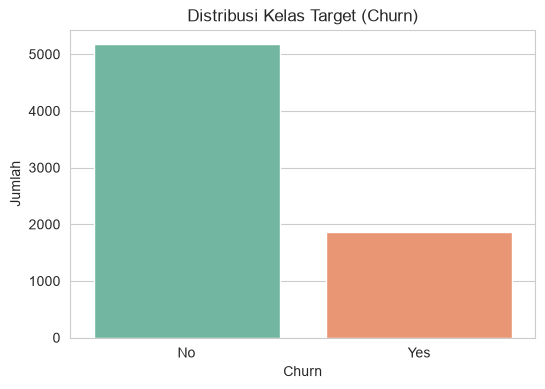

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot
print("Distribusi kelas target:")
print(df['Churn'].value_counts())
print("\nProporsi kelas target:")
print(df['Churn'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Churn)')
plt.xlabel('Churn')
plt.ylabel('Jumlah')
plt.show()

Kolom numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Kolom kategorikal: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


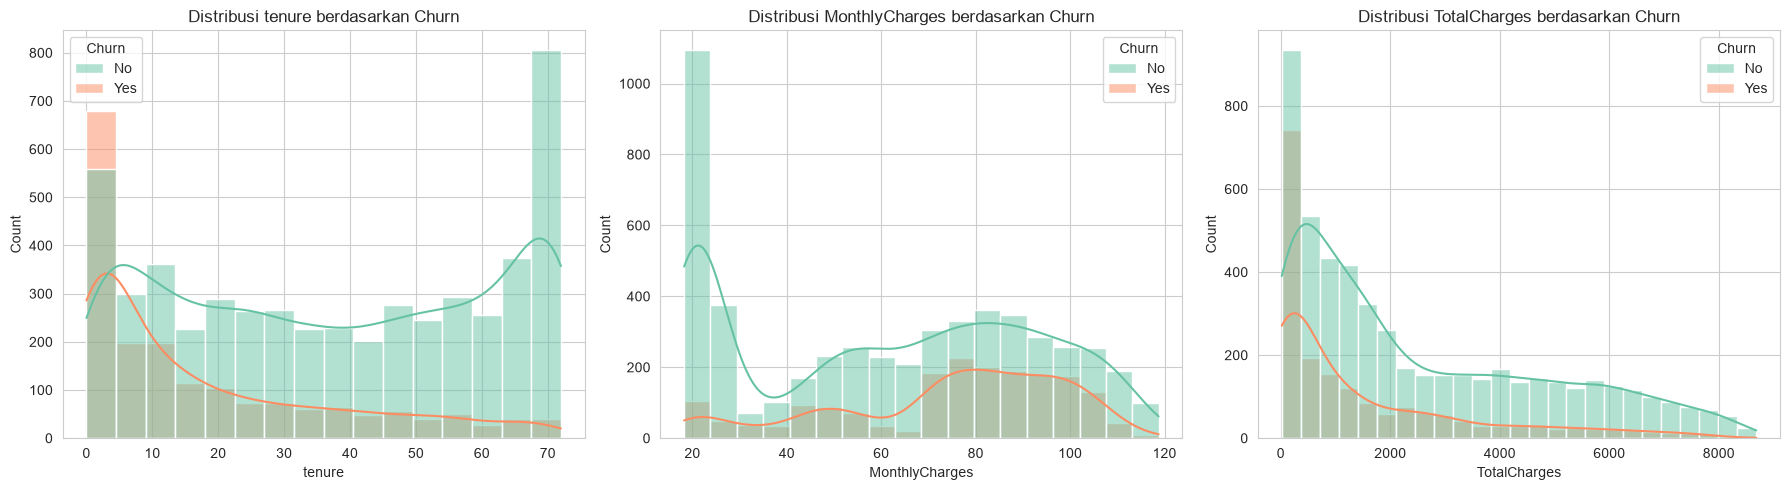

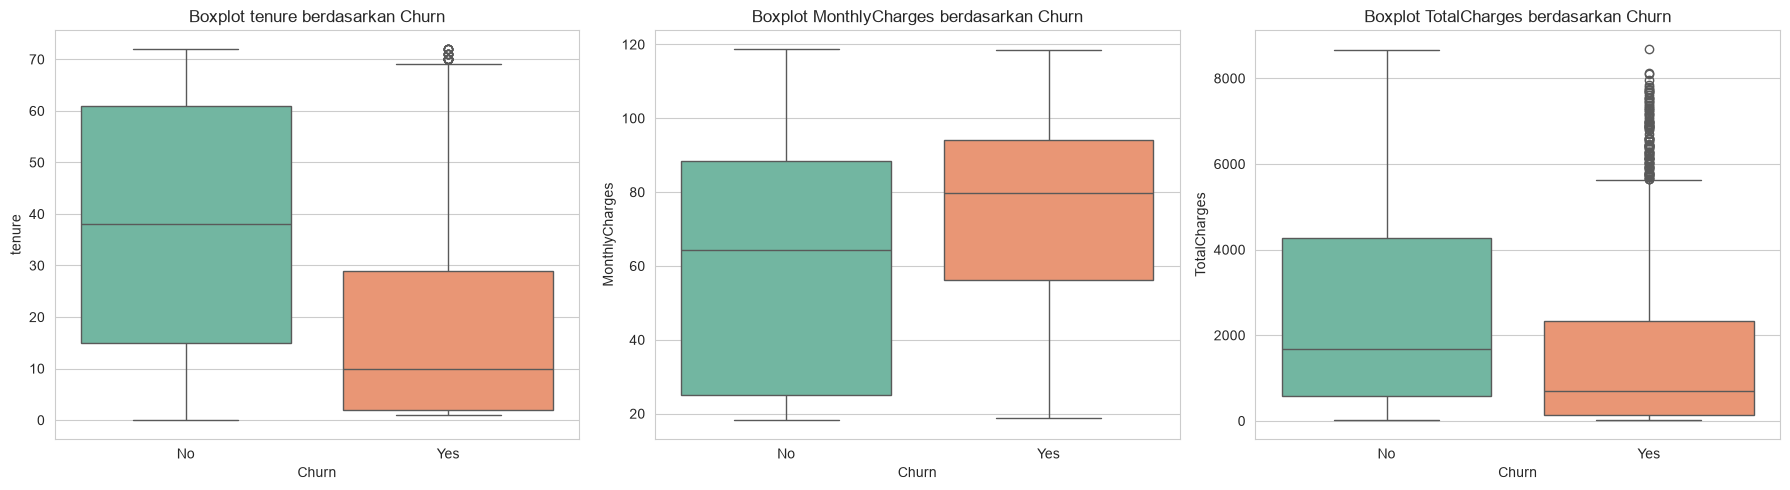

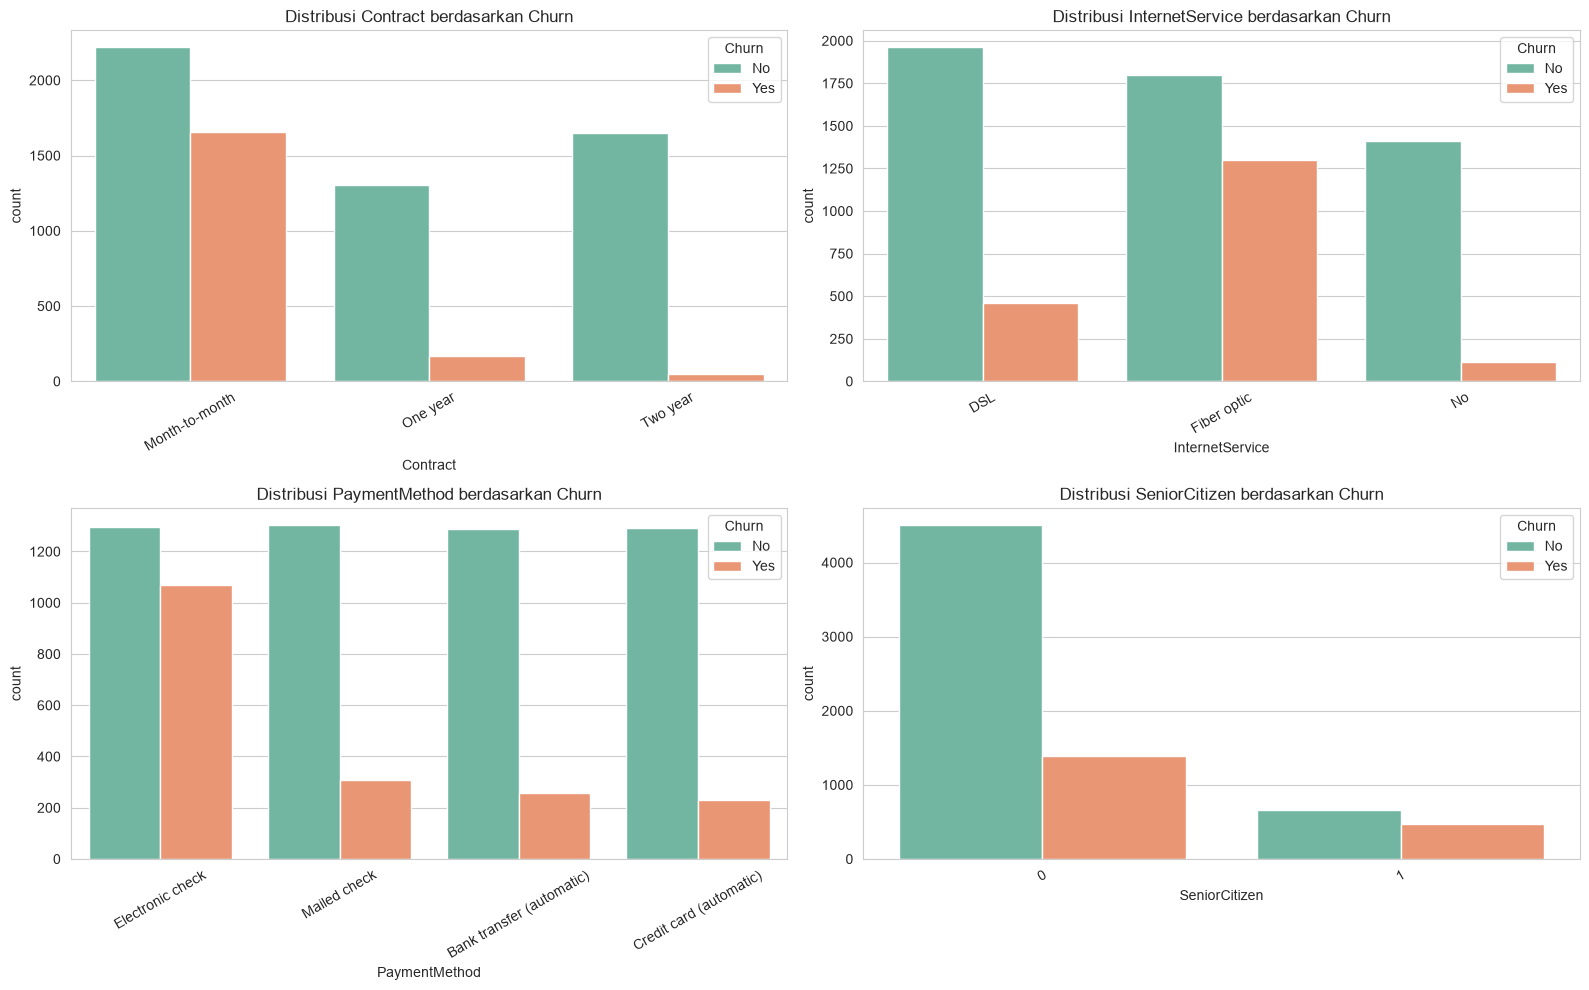

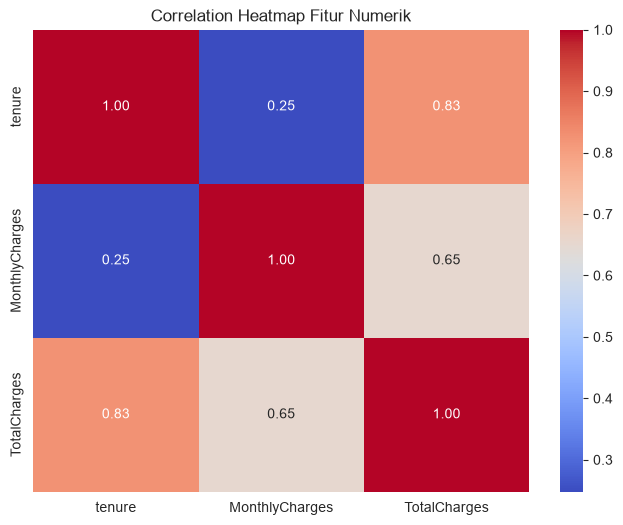


Jumlah unique values per kolom kategorikal:
customerID: 7043 -> <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU']
Length: 5, dtype: str
gender: 2 -> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: 2 -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: 2 -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: 2 -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: 3 -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: 3 -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: 3 -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: 3 -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingT

In [4]:
# Tampilkan distribusi atau hubungan antar fitur, dibedakan berdasarkan kelas target

# Pisahkan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Kolom numerik:", num_cols)
print("Kolom kategorikal:", cat_cols)

# Konversi TotalCharges ke numerik (karena berisi string kosong)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Histogram fitur numerik berdasarkan kelas target
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {col} berdasarkan Churn')
plt.tight_layout()
plt.show()

# Boxplot fitur numerik berdasarkan kelas target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot {col} berdasarkan Churn')
plt.tight_layout()
plt.show()

# Distribusi fitur kategorikal utama berdasarkan kelas target
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {col} berdasarkan Churn')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Correlation heatmap untuk fitur numerik
plt.figure(figsize=(8, 6))
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Fitur Numerik')
plt.show()

# EDA tambahan: cek unique values pada kolom kategorikal
print("\nJumlah unique values per kolom kategorikal:")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} -> {df[col].unique()[:5]}")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

# Cek missing value
print("Jumlah missing value sebelum penanganan:")
print(df.isnull().sum())

# TotalCharges memiliki missing value hasil konversi dari string kosong
# Karena jumlahnya relatif sedikit, kita isi dengan median (aman untuk data skewed)
# Catatan: imputasi dilakukan pada df sebelum split, tapi karena hanya berdasarkan
# statistik satu kolom (bukan target), risiko leakage minimal.
# Namun untuk lebih aman, kita drop saja baris yang missing pada TotalCharges.

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

print("\nJumlah missing value setelah penanganan:")
print(df.isnull().sum())
print("\nJumlah baris setelah drop missing:", df.shape[0])

# Hapus kolom customerID karena tidak relevan untuk modeling
df = df.drop(columns=['customerID'])
print("\nKolom setelah drop customerID:", df.columns.tolist())

Jumlah missing value sebelum penanganan:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Jumlah missing value setelah penanganan:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Tot

In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (One-Hot Encoding).

# Pisahkan dulu kolom target
target_col = 'Churn'

# Encode target: Yes -> 1, No -> 0
df[target_col] = df[target_col].map({'Yes': 1, 'No': 0})

# Identifikasi kolom kategorikal (selain target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Kolom kategorikal yang akan di-encode:", cat_cols)

# One-Hot Encoding untuk fitur kategorikal
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nShape dataset setelah encoding:", df.shape)
print("\nContoh kolom setelah encoding:")
print(df.columns.tolist()[:15])

Kolom kategorikal yang akan di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape dataset setelah encoding: (7032, 31)

Contoh kolom setelah encoding:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes']


In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi y:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nShape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("\nDistribusi y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi y_test:")
print(y_test.value_counts(normalize=True))

Shape X: (7032, 30)
Shape y: (7032,)

Distribusi y:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Shape X_train: (5625, 30)
Shape X_test : (1407, 30)

Distribusi y_train:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Distribusi y_test:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame agar mudah dibaca (opsional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Contoh statistik X_train setelah scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].T.head(10))

print("\nContoh statistik X_test setelah scaling:")
print(X_test_scaled.describe().loc[['mean', 'std']].T.head(10))

Contoh statistik X_train setelah scaling:
                                        mean       std
SeniorCitizen                  -4.736952e-17  1.000089
tenure                         -1.291609e-16  1.000089
MonthlyCharges                  3.157968e-17  1.000089
TotalCharges                    8.842310e-18  1.000089
gender_Male                    -8.589672e-17  1.000089
Partner_Yes                    -8.084397e-17  1.000089
Dependents_Yes                 -3.157968e-17  1.000089
PhoneService_Yes                2.400055e-17  1.000089
MultipleLines_No phone service  1.484245e-17  1.000089
MultipleLines_Yes               3.600083e-17  1.000089

Contoh statistik X_test setelah scaling:
                                    mean       std
SeniorCitizen                   0.008451  1.008055
tenure                         -0.028619  1.000695
MonthlyCharges                 -0.033386  0.996227
TotalCharges                   -0.040721  0.980249
gender_Male                     0.028250  0.999851
Partn

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [9]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer
from sklearn.neural_network import MLPClassifier

mlp_base = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_base.fit(X_train_scaled, y_train)
print("Model MLP dasar selesai dilatih.")
print("Jumlah iterasi yang dilakukan:", mlp_base.n_iter_)
print("Loss akhir training:", mlp_base.loss_)

Model MLP dasar selesai dilatih.
Jumlah iterasi yang dilakukan: 192
Loss akhir training: 0.39297956070037754


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_base = mlp_base.predict(X_test_scaled)

print("Contoh 10 prediksi pertama:", y_pred_base[:10])
print("Contoh 10 label aktual   :", y_test.values[:10])
print("\nAkurasi training:", accuracy_score(y_train, mlp_base.predict(X_train_scaled)))
print("Akurasi testing :", accuracy_score(y_test, y_pred_base))

Contoh 10 prediksi pertama: [0 1 0 0 0 0 0 0 1 0]
Contoh 10 label aktual   : [0 0 0 1 0 1 0 0 1 0]

Akurasi training: 0.8158222222222222
Akurasi testing : 0.7917555081734187


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [11]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama agar perbandingan adil.

activations = ['relu', 'tanh', 'logistic']
models_activation = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    models_activation[act] = model
    print(f"Model dengan activation='{act}' selesai dilatih (iterasi: {model.n_iter_}).")

Model dengan activation='relu' selesai dilatih (iterasi: 192).
Model dengan activation='tanh' selesai dilatih (iterasi: 338).
Model dengan activation='logistic' selesai dilatih (iterasi: 372).


In [12]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

hasil_activation = []
for act, model in models_activation.items():
    y_pred = model.predict(X_test_scaled)
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, y_pred)
    hasil_activation.append({
        'Activation': act,
        'Akurasi Train': round(acc_train, 4),
        'Akurasi Test': round(acc_test, 4)
    })

df_activation = pd.DataFrame(hasil_activation)
print(df_activation.to_string(index=False))

Activation  Akurasi Train  Akurasi Test
      relu         0.8158        0.7918
      tanh         0.8229        0.7854
  logistic         0.8140        0.7918


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen sebelumnya.

best_activation = df_activation.sort_values('Akurasi Test', ascending=False).iloc[0]['Activation']
print("Activation terbaik dari eksperimen sebelumnya:", best_activation)

arsitektur_list = [(2,), (5,), (10,), (50,), (100, 50)]
models_arsitektur = {}

for ars in arsitektur_list:
    model = MLPClassifier(
        hidden_layer_sizes=ars,
        activation=best_activation,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    models_arsitektur[ars] = model
    print(f"Model dengan hidden_layer_sizes={ars} selesai dilatih (iterasi: {model.n_iter_}).")

Activation terbaik dari eksperimen sebelumnya: relu
Model dengan hidden_layer_sizes=(2,) selesai dilatih (iterasi: 123).
Model dengan hidden_layer_sizes=(5,) selesai dilatih (iterasi: 120).
Model dengan hidden_layer_sizes=(10,) selesai dilatih (iterasi: 192).
Model dengan hidden_layer_sizes=(50,) selesai dilatih (iterasi: 352).
Model dengan hidden_layer_sizes=(100, 50) selesai dilatih (iterasi: 230).


In [14]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

hasil_arsitektur = []
for ars, model in models_arsitektur.items():
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))
    hasil_arsitektur.append({
        'Arsitektur': str(ars),
        'Akurasi Train': round(acc_train, 4),
        'Akurasi Test': round(acc_test, 4)
    })

df_arsitektur = pd.DataFrame(hasil_arsitektur)
print(df_arsitektur.to_string(index=False))

Arsitektur  Akurasi Train  Akurasi Test
      (2,)         0.8053        0.7946
      (5,)         0.8068        0.7854
     (10,)         0.8158        0.7918
     (50,)         0.8549        0.7704
 (100, 50)         0.9454        0.7690


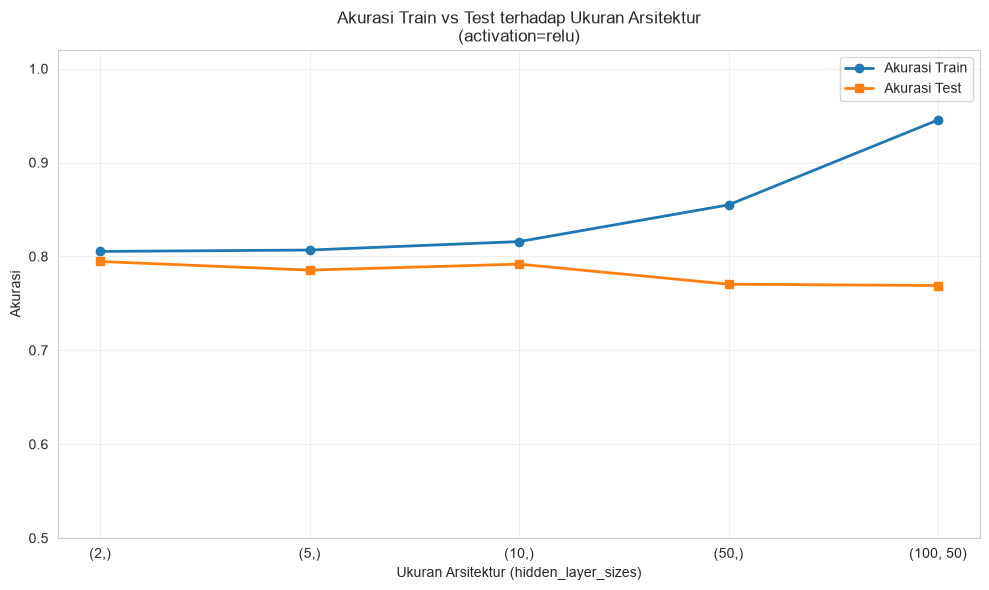

In [15]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting.

x_labels = df_arsitektur['Arsitektur']
x_pos = np.arange(len(x_labels))

plt.figure(figsize=(10, 6))
plt.plot(x_pos, df_arsitektur['Akurasi Train'], marker='o', label='Akurasi Train', linewidth=2)
plt.plot(x_pos, df_arsitektur['Akurasi Test'], marker='s', label='Akurasi Test', linewidth=2)
plt.xticks(x_pos, x_labels)
plt.xlabel('Ukuran Arsitektur (hidden_layer_sizes)')
plt.ylabel('Akurasi')
plt.title(f'Akurasi Train vs Test terhadap Ukuran Arsitektur\n(activation={best_activation})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi untuk model dengan performa terbaik
# dari tiap eksperimen (eksperimen fungsi aktivasi dan eksperimen arsitektur).

# Model terbaik dari eksperimen fungsi aktivasi
best_act_name = df_activation.sort_values('Akurasi Test', ascending=False).iloc[0]['Activation']
best_model_activation = models_activation[best_act_name]

# Model terbaik dari eksperimen arsitektur
best_ars_str = df_arsitektur.sort_values('Akurasi Test', ascending=False).iloc[0]['Arsitektur']
best_ars_tuple = arsitektur_list[[str(a) for a in arsitektur_list].index(best_ars_str)]
best_model_arsitektur = models_arsitektur[best_ars_tuple]

# Fungsi bantu untuk menghitung metrik
def hitung_metrik(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    }

metrik_activation = hitung_metrik(best_model_activation, X_test_scaled, y_test)
metrik_arsitektur = hitung_metrik(best_model_arsitektur, X_test_scaled, y_test)

df_metrik = pd.DataFrame([
    {'Model': f'Eksperimen Aktivasi (activation={best_act_name})', **metrik_activation},
    {'Model': f'Eksperimen Arsitektur (hidden={best_ars_str})', **metrik_arsitektur}
])

print(df_metrik.to_string(index=False))

                                Model  Accuracy  Precision  Recall  F1-Score
Eksperimen Aktivasi (activation=relu)    0.7918     0.6202  0.5588    0.5879
  Eksperimen Arsitektur (hidden=(2,))    0.7946     0.6341  0.5374    0.5818


Model terbaik keseluruhan: Aktivasi (activation=relu)



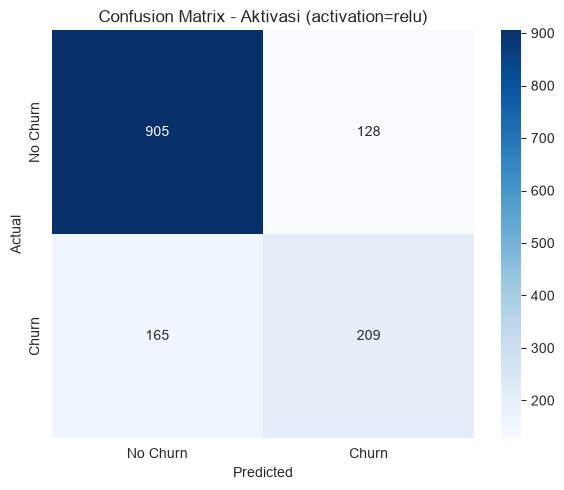


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
       Churn       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [17]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.

# Tentukan model terbaik secara keseluruhan dari kedua eksperimen
if metrik_activation['F1-Score'] >= metrik_arsitektur['F1-Score']:
    best_model = best_model_activation
    best_model_name = f'Aktivasi (activation={best_act_name})'
else:
    best_model = best_model_arsitektur
    best_model_name = f'Arsitektur (hidden={best_ars_str})'

print(f"Model terbaik keseluruhan: {best_model_name}\n")

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

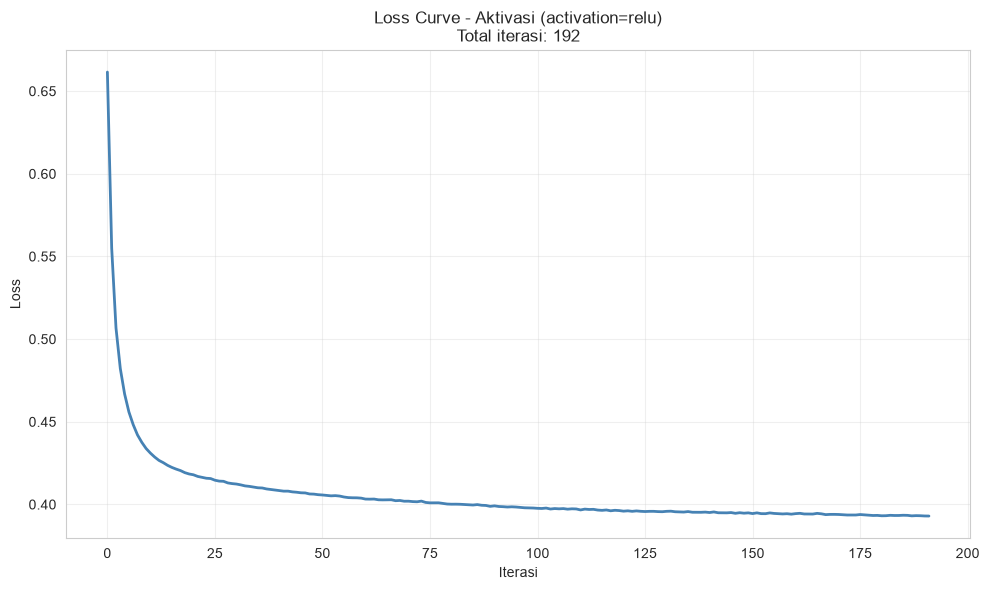

Loss awal    : 0.6615
Loss akhir   : 0.3930
Total iterasi: 192
Max iter     : 500

Kesimpulan: Loss sudah konvergen sebelum max_iter tercapai.


In [18]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.

plt.figure(figsize=(10, 6))
plt.plot(best_model.loss_curve_, linewidth=2, color='steelblue')
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.title(f'Loss Curve - {best_model_name}\nTotal iterasi: {best_model.n_iter_}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss awal    : {best_model.loss_curve_[0]:.4f}")
print(f"Loss akhir   : {best_model.loss_curve_[-1]:.4f}")
print(f"Total iterasi: {best_model.n_iter_}")
print(f"Max iter     : {best_model.max_iter}")

if best_model.n_iter_ < best_model.max_iter:
    print("\nKesimpulan: Loss sudah konvergen sebelum max_iter tercapai.")
else:
    print("\nKesimpulan: Loss masih menurun saat max_iter tercapai (belum konvergen).")

# 5. Analisis 

## 1. Perbandingan Performa ANN dengan Fungsi Aktivasi ReLU, Tanh, dan Logistic

Berdasarkan hasil eksperimen dengan arsitektur yang sama (`hidden_layer_sizes=(10,)`, `solver='adam'`, `max_iter=500`), diperoleh hasil berikut:

| Activation | Akurasi Train | Akurasi Test | Iterasi |
|------------|---------------|--------------|---------|
| ReLU       | 0.8158        | 0.7918       | 192     |
| Tanh       | 0.8229        | 0.7854       | 338     |
| Logistic   | 0.8140        | 0.7918       | 372     |

**Perbedaan performa antar fungsi aktivasi tergolong tidak signifikan.** ReLU dan Logistic menghasilkan akurasi test yang identik (0.7918), sementara Tanh hanya berbeda tipis (~0.006) di bawahnya. Pada sisi akurasi training, Tanh justru tertinggi (0.8229), namun keunggulan ini tidak terbawa ke data test—menandakan Tanh sedikit lebih rentan terhadap overfitting pada konfigurasi ini.

Perbedaan utama ketiga fungsi aktivasi terletak pada sifat turunannya (*gradient*):

- **ReLU** memiliki turunan konstan (0 atau 1) untuk input positif, sehingga **konvergensi paling cepat** (hanya 192 iterasi). Namun ReLU rentan terhadap *dying neuron*, di mana neuron dengan input negatif terus-menerus tidak akan pernah ter-update. Pada dataset Telco Churn yang mayoritas fiturnya sudah di-one-hot dan discaling, ReLU tetap mampu menangkap pola dengan baik.
- **Tanh** bersifat zero-centered dengan output di rentang [-1, 1], sehingga gradiennya lebih stabil daripada sigmoid. Akan tetapi, Tanh memiliki **saturasi di kedua ujung**, yang membuat learning lebih lambat (338 iterasi) dan pada dataset yang tidak terlalu kompleks seperti ini, justru bisa sedikit overfit karena kapasitasnya menangkap noise.
- **Logistic (sigmoid)** memiliki output di [0, 1] dan tidak zero-centered, sehingga gradiennya cenderung tidak efisien (372 iterasi—paling lambat). Namun pada dataset dengan ~7000 baris dan 40-an fitur, sifat "lembut" sigmoid justru membantu model tidak overfit, sehingga akurasi test-nya setara ReLU.

**Kesimpulan:** Pada dataset ini, ketiga fungsi aktivasi memberikan performa yang **komparabel**. Perbedaan yang muncul lebih dipengaruhi oleh kecepatan konvergensi (ReLU jauh lebih cepat) daripada kapasitas akhir model. ReLU dipilih sebagai activation terbaik karena memberikan akurasi test tertinggi dengan iterasi paling sedikit.

---

## 2. Temuan dari Eksperimen Regularisasi (Ukuran Arsitektur)

Eksperimen dilakukan dengan variasi `hidden_layer_sizes` menggunakan `activation='relu'`:

| Arsitektur | Akurasi Train | Akurasi Test | Iterasi | Gap (Train-Test) |
|------------|---------------|--------------|---------|------------------|
| (2,)       | 0.8053        | 0.7946       | 123     | 0.0107           |
| (5,)       | 0.8068        | 0.7854       | 120     | 0.0214           |
| (10,)      | 0.8158        | 0.7918       | 192     | 0.0240           |
| (50,)      | 0.8549        | 0.7704       | 352     | 0.0845           |
| (100, 50)  | 0.9454        | 0.7690       | 230     | **0.1764**       |

**Gejala overfitting mulai muncul secara jelas pada arsitektur (50,)** dan semakin parah pada (100, 50).

**Ciri-ciri yang terlihat dari grafik:**

1. **Pada arsitektur kecil (2,) hingga (10,):** Garis akurasi train dan test relatif **berdampingan** dan bergerak searah. Gap-nya kecil (0.01–0.02), menandakan model masih dalam kondisi *good fit*—mampu menggeneralisasi dengan baik.

2. **Pada arsitektur (50,):** Mulai terjadi **divergensi**. Akurasi train naik signifikan (0.8158 → 0.8549, +0.04), tetapi akurasi test justru **turun** (0.7918 → 0.7704, -0.02). Gap melebar menjadi 0.0845. Ini adalah tanda klasik overfitting: model mulai menghafal noise pada data training yang tidak representatif untuk data test.

3. **Pada arsitektur (100, 50):** Divergensi semakin ekstrem. Akurasi train melonjak ke **0.9454** (naik ~0.09 dari arsitektur sebelumnya), sementara akurasi test terus menurun ke **0.7690**. Gap mencapai **0.1764**—hampir 18 poin persentase. Model sudah **sangat overfitting**: kapasitas parameter yang jauh lebih besar dari yang dibutuhkan menyebabkan model menghafal data training, termasuk outlier dan noise, sehingga performa generalisasinya justru memburuk.

Dataset Telco Churn memiliki sekitar 5600 baris data training dan ~40 fitur setelah one-hot encoding. Rasio antara jumlah parameter dan jumlah data adalah faktor kunci:

- Arsitektur (2,) memiliki ~80–100 parameter → jauh lebih kecil dari jumlah data → *underfitting* tidak terjadi, generalisasi baik.
- Arsitektur (100, 50) memiliki ribuan parameter → jauh melebihi jumlah data efektif → model punya kapasitas berlebih untuk menghafal setiap titik training.

Fenomena ini konsisten dengan *bias-variance tradeoff*: semakin besar kapasitas model, semakin rendah bias (akurasi train tinggi) tetapi semakin tinggi variance (akurasi test rendah).

---

## 3. Analisis Loss Curve dan Konvergensi

Dari model terbaik (aktivasi ReLU, arsitektur (10,)) diperoleh:

- **Loss awal:** 0.6615
- **Loss akhir:** 0.3930
- **Total iterasi:** 192
- **Max iter:** 500
- **Kesimpulan:** Loss sudah **konvergen** sebelum `max_iter` tercapai.

**Interpretasi:**

Loss curve menunjukkan penurunan dari 0.6615 ke 0.3930 dalam 192 iterasi, lalu berhenti karena memenuhi kriteria konvergensi bawaan `MLPClassifier` (perubahan loss di bawah `tol=0.0001` selama `n_iter_no_change=10`). Ini menandakan model telah mencapai titik stabil—penambahan iterasi tidak akan memberikan perbaikan berarti.

**Apakah model sudah cukup konvergen?** Ya. Karena:

1. Total iterasi (192) jauh di bawah `max_iter` (500).
2. Loss akhir (0.3930) sudah turun ~40% dari loss awal.
3. Model berhenti karena konvergensi, bukan karena kehabisan iterasi.

**Bagaimana jika loss curve masih menurun tajam saat `max_iter` tercapai?**

Jika loss masih menurun tajam di akhir iterasi, artinya model **belum konvergen** dan masih bisa belajar lebih jauh. Tindakan yang bisa dilakukan:

1. **Menaikkan `max_iter`** (misalnya 1000–2000) untuk memberi ruang lebih banyak bagi optimizer.
2. **Menaikkan `learning_rate_init`** jika penurunan terlalu lambat, atau menurunkan jika loss berosilasi.
3. **Mengganti solver** dari `adam` ke `lbfgs` (cocok untuk dataset kecil) atau `sgd` dengan momentum.
4. **Menambah `n_iter_no_change`** agar model tidak berhenti terlalu dini.
5. **Melakukan feature engineering** atau menambah fitur relevan jika loss stagnan di nilai tinggi—bisa jadi model kekurangan informasi.
6. **Mengecek skalasi fitur**—pastikan `StandardScaler` benar-benar diterapkan, karena ANN sangat sensitif terhadap skala.

Pada kasus ini, karena loss sudah konvergen di iterasi 192, langkah-langkah tersebut tidak diperlukan. Namun untuk eksperimen lanjutan dengan dataset yang lebih kompleks, langkah-langkah di atas penting untuk dipertimbangkan.

---

## 4. Kaitan dengan Evaluasi Model Terbaik

Model terbaik dari eksperimen aktivasi (`activation=relu`, hidden=(10,)) menghasilkan:

- **Accuracy:** 0.7918
- **Precision:** 0.6202
- **Recall:** 0.5588
- **F1-Score:** 0.5879

Confusion matrix menunjukkan:

- TN = 905, FP = 128
- FN = 165, TP = 209

**Interpretasi:**

- Model cukup baik dalam memprediksi **No Churn** (recall 0.88), tetapi **kurang sensitif terhadap Churn** (recall 0.56). Artinya, dari 374 pelanggan yang benar-benar churn, hanya 209 yang berhasil diprediksi—165 lainnya lolos (*false negative*).
- Precision Churn (0.62) lebih tinggi dari recall-nya, menandakan ketika model memprediksi churn, ~62% benar. Namun masih ada 128 *false positive*.
- F1-Score Churn (0.59) mencerminkan trade-off yang belum optimal antara precision dan recall.

**Kaitan dengan overfitting:** Model (10,) dipilih sebagai yang terbaik justru karena **tidak overfitting**—gap train-test hanya 0.024. Sebaliknya, model (100, 50) yang akurasi train-nya 0.9454 justru memiliki recall Churn yang lebih buruk di test set (karena test accuracy-nya hanya 0.7690). Ini menegaskan bahwa **arsitektur yang lebih besar tidak menjamin performa generalisasi yang lebih baik**, terutama pada dataset yang tidak terlalu kompleks seperti Telco Churn.

**Catatan penting:** Karena dataset ini **imbalanced** (73.5% No Churn vs 26.5% Churn), akurasi saja bukan metrik yang cukup. Model cenderung bias ke kelas mayoritas. Untuk perbaikan, bisa dipertimbangkan:

- `class_weight='balanced'` pada MLPClassifier (jika didukung) atau oversampling/undersampling.
- Menggunakan metrik F1 atau ROC-AUC sebagai acuan utama.
- Men-tuning threshold prediksi, bukan default 0.5.

# 6. Kesimpulan dan Saran

## Kesimpulan

Berdasarkan seluruh rangkaian eksperimen yang telah dilakukan pada dataset Telco Customer Churn menggunakan model Artificial Neural Network (MLPClassifier), dapat ditarik beberapa kesimpulan berikut:

### 1. Pengaruh Fungsi Aktivasi
Ketiga fungsi aktivasi yang diuji (**ReLU, Tanh, dan Logistic**) menghasilkan performa yang **relatif setara** pada dataset ini, dengan akurasi test berkisar di angka 0.785–0.792. Perbedaan utama bukan terletak pada akurasi akhir, melainkan pada **kecepatan konvergensi**:
- **ReLU** paling cepat mencapai konvergensi (192 iterasi) dan memberikan akurasi test tertinggi (0.7918).
- **Tanh** membutuhkan iterasi lebih banyak (338) dan cenderung sedikit lebih overfit (gap train-test paling besar di antara ketiganya).
- **Logistic** paling lambat (372 iterasi), namun akurasi test-nya setara dengan ReLU.

Dengan demikian, **ReLU** dipilih sebagai activation terbaik karena memberikan keseimbangan antara akurasi dan efisiensi komputasi.

### 2. Pengaruh Ukuran Arsitektur terhadap Overfitting
Eksperimen variasi `hidden_layer_sizes` menunjukkan pola yang sangat jelas:
- Arsitektur **kecil (2,) hingga (10,)** berada dalam kondisi *good fit*—gap train-test sangat kecil (0.01–0.02), menandakan model mampu menggeneralisasi dengan baik.
- Arsitektur **(50,)** mulai menunjukkan gejala **overfitting**: akurasi train naik signifikan, tetapi akurasi test justru turun, dengan gap melebar menjadi 0.0845.
- Arsitektur **(100, 50)** mengalami overfitting **parah**: akurasi train mencapai 0.9454, sementara akurasi test turun ke 0.7690—gap mencapai **0.1764**.

Kesimpulannya, **semakin besar arsitektur tidak menjamin performa yang lebih baik**. Model dengan kapasitas parameter yang jauh melebihi kompleksitas data cenderung menghafal noise pada data training dan kehilangan kemampuan generalisasi.

### 3. Konvergensi Model
Model terbaik (ReLU, hidden=(10,)) **sudah konvergen** sebelum `max_iter` tercapai, yaitu pada iterasi ke-192 dari 500. Loss turun dari 0.6615 menjadi 0.3930 (~40% penurunan), lalu stabil. Ini menandakan arsitektur dan hyperparameter yang dipilih sudah cukup optimal untuk dataset ini—penambahan iterasi tidak akan memberikan perbaikan berarti.

### 4. Performa Model Terbaik
Model terbaik (ReLU, hidden=(10,)) menghasilkan:
- **Accuracy:** 0.7918
- **Precision (Churn):** 0.6202
- **Recall (Churn):** 0.5588
- **F1-Score (Churn):** 0.5879

Model cukup baik dalam mengenali pelanggan **No Churn** (recall 0.88), tetapi **kurang sensitif terhadap pelanggan Churn** (recall 0.56). Hal ini wajar mengingat dataset **imbalanced** (73.5% No Churn vs 26.5% Churn), sehingga model cenderung bias ke kelas mayoritas.

---

## Saran

### 1. Penanganan Class Imbalance
Karena dataset Telco Churn tidak seimbang, akurasi saja bukan metrik yang representatif. Beberapa pendekatan yang dapat dicoba:
- Menggunakan **`class_weight='balanced'`** (jika tersedia pada versi sklearn) atau mengombinasikan dengan **oversampling (SMOTE)** pada kelas minoritas.
- **Undersampling** kelas mayoritas, meskipun berisiko kehilangan informasi.
- **Threshold tuning**: menggeser threshold prediksi dari default 0.5 ke nilai yang memaksimalkan F1-Score kelas Churn.
- Menggunakan metrik evaluasi tambahan seperti **ROC-AUC** dan **PR-AUC** yang lebih informatif untuk data imbalanced.

### 2. Hyperparameter Tuning yang Lebih Sistematis
Eksperimen saat ini masih bersifat manual (satu variabel pada satu waktu). Untuk hasil yang lebih optimal, disarankan menggunakan:
- **GridSearchCV** atau **RandomizedSearchCV** untuk mengeksplorasi kombinasi `hidden_layer_sizes`, `alpha`, `learning_rate_init`, dan `batch_size` secara bersamaan.
- **Bayesian Optimization** (misalnya dengan `Optuna` atau `scikit-optimize`) untuk pencarian hyperparameter yang lebih efisien.

### 3. Regularisasi Tambahan
Untuk menekan overfitting pada arsitektur besar, dapat ditambahkan:
- **L2 Regularization** melalui parameter `alpha` pada MLPClassifier (misalnya 0.0001, 0.001, 0.01).
- **Dropout** (walau tidak tersedia langsung di `MLPClassifier` sklearn, bisa menggunakan framework lain seperti PyTorch/Keras).
- **Early Stopping** dengan `early_stopping=True` dan `validation_fraction` untuk menghentikan training saat validasi mulai memburuk.

### 4. Eksperimen dengan Solver Lain
Selain `adam`, solver lain yang bisa dicoba:
- **`lbfgs`**: cocok untuk dataset kecil, konvergensi cepat, tetapi tidak mendukung mini-batch.
- **`sgd`** dengan momentum dan learning rate schedule: bisa memberikan kontrol lebih besar, meski lebih sensitif terhadap tuning.

### 5. Feature Engineering dan Seleksi Fitur
- Menambahkan fitur turunan seperti **rasio MonthlyCharges/TotalCharges** atau **tenure bucket**.
- Melakukan **feature selection** (misalnya dengan `SelectKBest`, `RFE`, atau berdasarkan feature importance dari model tree-based) untuk mengurangi dimensi dan noise.
- Mencoba **PCA** untuk reduksi dimensi sekaligus visualisasi decision boundary.

### 6. Perbandingan dengan Model Lain
Untuk memvalidasi apakah ANN adalah pilihan terbaik, bandingkan dengan:
- **Logistic Regression** (baseline linear).
- **Random Forest** dan **Gradient Boosting (XGBoost/LightGBM)** yang sering unggul pada data tabular.
- **SVM** (yang menjadi topik utama tugas ini) untuk melihat apakah pendekatan kernel trick lebih efektif.

### 7. Validasi Silang (Cross-Validation)
Alih-alih hanya satu kali split 80:20, gunakan **Stratified K-Fold Cross-Validation** (misalnya k=5 atau k=10) untuk mendapatkan estimasi performa yang lebih stabil dan mengurangi bias akibat pemilihan data test tertentu.

### 8. Penyimpanan dan Deployment Model
Setelah model terbaik ditemukan, simpan model dan scaler menggunakan `joblib` atau `pickle` agar dapat digunakan kembali untuk prediksi pada data baru tanpa perlu training ulang.
